# 02 · 베이스라인 → 하이브리드 융합 (B0~B4, P1, P2)

`scripts/run_experiments.py --profile full` 이 생성하는 단계들.

| run | 기법 |
|---|---|
| B0 | TF-IDF 통계 추출 |
| B1/B2 | KeyBERT (임베딩 유사도) / +MMR |
| B3/B4 | BART / KeyBART seq2seq **생성** (beam5) |
| P1 | **Hybrid 융합** — 추출(KeyBERT)+생성(KeyBART) 후보를 점수 융합으로 정렬 |
| P2 | **Hybrid 융합 + MMR(λ=0.5)** — 비학습 최고 (exact F1) |

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings("ignore")

# repo 루트 자동 탐색 (results/ 가 있는 곳) — 노트북을 어디서 열든 동작
ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))            # src.* import 가능
sys.path.insert(0, str(ROOT / "scripts"))  # 스크립트 모듈 import 가능
print("repo root:", ROOT)

repo root: C:\Users\wodlf\OneDrive\Desktop\kp20k-keyphrase-extraction


In [2]:
grand = pd.read_csv(ROOT / "results/metrics/grand_comparison_all_models.csv")
base = ["B0_tfidf_full","B1_keybert_full","B2_keybert_mmr_full","B3_bart_beam5_full",
        "B4_keybart_beam5_full","P1_hybrid_fusion_full","P2_hybrid_fusion_mmr_full"]
grand[grand.run_id.isin(base)][["run_id","model","F1@5","F1@10","present_F1@5","absent_R@10"]].reset_index(drop=True)

,run_id,model,F1@5,F1@10,present_F1@5,absent_R@10
0,B0_tfidf_full,TF-IDF,0.1261,0.1142,0.1734,0.0113
1,B1_keybert_full,KeyBERT,0.0502,0.0601,0.1369,0.0060
2,B2_keybert_mmr_full,KeyBERT+MMR,0.0285,0.0270,0.0590,0.0035
3,B3_bart_beam5_full,BART,0.2445,0.1711,0.3039,0.0132
4,B4_keybart_beam5_full,KeyBART,0.2377,0.1672,0.2965,0.0097
5,P1_hybrid_fusion_full,Hybrid,0.2070,0.1842,0.3137,0.0323
6,P2_hybrid_fusion_mmr_full,Hybrid+MMR,0.2560,0.2105,0.3420,0.0219


### 실제 예측 예시 — P2(hybrid+MMR) 문서별 결과

In [3]:
# results/predictions_per_document/ 는 scripts 산출물의 정리본
p2 = pd.read_csv(ROOT / "results/predictions_per_document/11_hybrid_fusion_mmr.csv")
row = p2.iloc[0]
print("제목      :", row["title"])
print("정답 gold :", row["gold"])
print("예측 top10:", row["pred_top10"], "   ([O]=정답 적중)")
print("F1@5 =", row["F1@5"], " R@10 =", row["R@10"])

제목      : A feedback vertex set of 2-degenerate graphs
정답 gold : feedback vertex set; 2-degenerate graphs; decycling set
예측 top10: [O] feedback vertex set; [O] 2-degenerate graph; forest; degenerate graphs feedback; vertex graph bound; algorithm; vertex set degenerate; set degenerate graphs; subgraph vertex dg; 2n degenerate vertex    ([O]=정답 적중)
F1@5 = 0.5  R@10 = 0.6667


In [4]:
from IPython.display import display
p2[["title","gold","pred_top10","F1@5","R@10"]].head(5)

,title,gold,pred_top10,F1@5,R@10
0,A feedback vertex set of 2-degenerate graphs,feedback vertex set; 2-degenerate graphs; decy...,[O] feedback vertex set; [O] 2-degenerate grap...,0.5000,0.6667
1,Hybrid Analytical Modeling of Pending Cache Hi...,analytical modeling; data prefetching; perform...,[O] data prefetching; [O] analytical modeling;...,0.4000,0.6000
2,Autoimmune polyendocrinopathy candidiasis ecto...,apeced; aire; chronic mucocutaneous candidiasi...,autoimmunity; mucocutaneous candidiasis; peced...,0.2000,0.2000
3,Numerical solution of a three-dimensional soli...,casting; convection; finite element; thermal; ...,aluminium casting; finite element method; solu...,0.0000,0.0000
4,Definition and recognition of rib features in ...,rib; aircraft structural part; feature recogni...,rib machining operations; [O] feature recognit...,0.4444,0.5000


### 베이스라인~하이브리드 F1@5

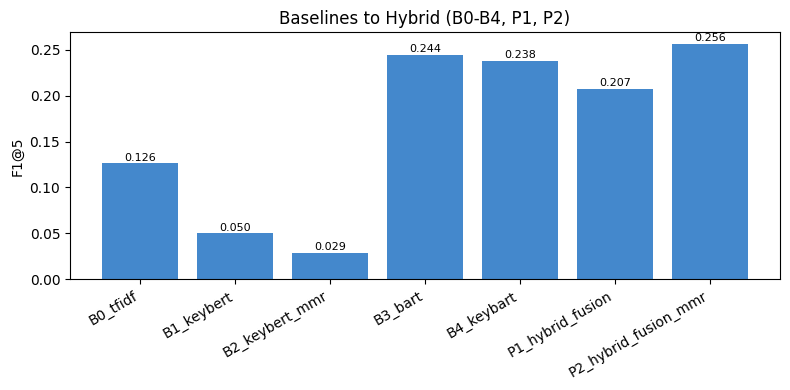

In [5]:
import matplotlib.pyplot as plt
d = grand[grand.run_id.isin(base)].copy()
d["short"] = d.run_id.str.replace("_full","",regex=False).str.replace("_beam5","",regex=False)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(d["short"], d["F1@5"], color="#48c")
ax.set_ylabel("F1@5"); ax.set_title("Baselines to Hybrid (B0-B4, P1, P2)")
plt.xticks(rotation=30, ha="right")
for i,v in enumerate(d["F1@5"]): ax.text(i, v+0.003, f"{v:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**관찰**: MMR이 융합(P1→P2) F1을 크게 올린다(0.207→0.256) — 융합 후보에 중복이 많아 다양화가 상위 K의 적중을 높이기 때문.
반대로 뒤(03)에서 볼 학습된 cross-encoder 랭커에는 MMR이 오히려 해가 된다. 구현: `src/reranking.py`, `src/diversity.py`.